In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer

In [5]:
data = load_breast_cancer()
X,y = data.data,data.target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=data.target)
print("X shape", X.shape)
print("Features", data.feature_names)


X shape (569, 30)
Features ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [6]:
def evaluate(name, **kwargs):
    t = DecisionTreeClassifier(random_state=42,**kwargs).fit(X_train,y_train)
    acc = accuracy_score(y_test,t.predict(X_test))
    print(f"{name:<35} test_acc={acc:.4f}  leaves={t.get_n_leaves():>3}  depth={t.get_depth()}")


evaluate("default (no limits)")                       # overfits
evaluate("max_depth=3",          max_depth=3)         # limit how deep
evaluate("min_samples_split=20", min_samples_split=20)# need >=20 samples to even split a node
evaluate("min_samples_leaf=10",  min_samples_leaf=10) # every leaf must hold >=10 samples
evaluate("max_leaf_nodes=8",     max_leaf_nodes=8)    # cap total number of leaves
evaluate("ccp_alpha=0.02",       ccp_alpha=0.02)      # cost-complexity pruning
evaluate("criterion='entropy'",  criterion="entropy")

default (no limits)                 test_acc=0.9123  leaves= 19  depth=7
max_depth=3                         test_acc=0.9386  leaves=  7  depth=3
min_samples_split=20                test_acc=0.9386  leaves= 11  depth=6
min_samples_leaf=10                 test_acc=0.9474  leaves= 10  depth=5
max_leaf_nodes=8                    test_acc=0.9386  leaves=  8  depth=4
ccp_alpha=0.02                      test_acc=0.8947  leaves=  4  depth=2
criterion='entropy'                 test_acc=0.9123  leaves= 16  depth=6


In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

importamces = tree.feature_importances_

order = np.argsort(importamces)[::-1]
print("Top features by importance:")
for i in order[:6]:
    print(f"  {data.feature_names[i]:<25} {importamces[i]:.3f}")

Top features by importance:
  worst radius              0.764
  worst concave points      0.127
  texture error             0.048
  worst texture             0.034
  worst concavity           0.018
  area error                0.010


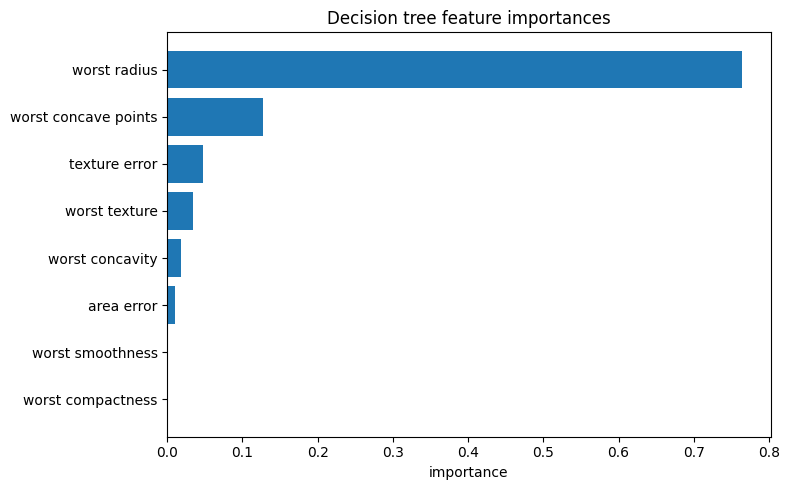

In [16]:
plt.figure(figsize=(8,5))
top = order[:8]
plt.barh([data.feature_names[i] for i in top][::-1],
         importamces[top][::-1])
plt.xlabel("importance"); plt.title("Decision tree feature importances")
plt.tight_layout(); plt.savefig("importances.png", dpi=110); plt.show()